<a href="https://colab.research.google.com/github/AaronYounger/Quantitative-Finance/blob/main/How_to_Mean_Reversion_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mean-Reversion**

In [1]:
!pip install openbb

INFO: pip is looking at multiple versions of requests-cache to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.8/379.8 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.8/99.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.5/125.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.3/190.3 kB 14.

In [2]:
import numpy as np
import pandas as pd
from openbb import obb
obb.user.preferences.output_type="dataframe"

In [4]:
# Get Data
symbol = ['AAPL']
data = obb.equity.price.historical(
    symbol = symbol,
    start_date = "2022-04-01",
    end_date = "2026-04-01",
    auto_adjust = True
)

In [5]:
# Create Log Returns
data['close_log_return'] = np.log(data['close']/data['close'].shift())

In [7]:
# Add Auto-Regression Columnn
data['close_log_return_lag_1'] = data['close_log_return'].shift()

In [8]:
# Encode direction
data['close_log_return_dir_lag_1'] = data['close_log_return_lag_1'].map(lambda x: 1 if x > 0 else -1)
print(data)

                  open        high         low       close    volume  \
date                                                                   
2022-04-01  174.029999  174.880005  171.940002  174.309998  78751300   
2022-04-04  174.570007  178.490005  174.440002  178.440002  76468400   
2022-04-05  177.500000  178.300003  174.419998  175.059998  73401800   
2022-04-06  172.360001  173.630005  170.130005  171.830002  89058800   
2022-04-07  171.160004  173.360001  169.850006  172.139999  77594700   
...                ...         ...         ...         ...       ...   
2026-03-26  252.119995  257.000000  250.770004  252.889999  41796700   
2026-03-27  253.899994  255.490005  248.070007  248.800003  47900000   
2026-03-30  250.070007  250.869995  245.509995  246.630005  39446200   
2026-03-31  247.910004  255.479996  247.100006  253.789993  49598100   
2026-04-01  254.080002  256.179993  253.330002  255.630005  40059400   

            dividend  close_log_return  close_log_return_lag_1 

In [9]:
# Study Price Movements
data.groupby('close_log_return_dir_lag_1').aggregate({'close_log_return':['sum', 'mean','count']})

close_log_return                
                                        sum      mean count
close_log_return_dir_lag_1                                 
-1                                 0.251498  0.000533   472
 1                                 0.131398  0.000248   530

The above chart is a great indicator to know whether a strategy is a contender mean reversion strategy. Ideally a potential stock for a mean reversion strategy would show opposite signs compared to the close_log_return_dir_lag_1. For example the sum and mean of the "1" row should be -0.13 and -0.00025, instead they are both positive. However trading off this table/indicator alone is dangerous, what if the sum and means show a totally different pattern in 2026.

In [10]:
# Out of sample validation
i = int(len(data)*0.75)
in_sample, out_sample = data.iloc[:i], data.iloc[i:]

In [13]:
in_sample.groupby('close_log_return_dir_lag_1').aggregate({'close_log_return':['sum', 'mean','count']})

close_log_return                
                                        sum      mean count
close_log_return_dir_lag_1                                 
-1                                 0.315649  0.000894   353
 1                                -0.068461 -0.000172   398

In [14]:
out_sample.groupby('close_log_return_dir_lag_1').aggregate({'close_log_return':['sum', 'mean','count']})

close_log_return                
                                        sum      mean count
close_log_return_dir_lag_1                                 
-1                                -0.064151 -0.000539   119
 1                                 0.199859  0.001514   132

Display Equity Curve

In [15]:
data['signal'] = -1 * data['close_log_return_dir_lag_1']

,open,high,low,close,volume,dividend,close_log_return,close_log_return_lag_1,close_log_return_dir_lag_1,signal
date,,,,,,,,,,
2022-04-01,174.029999,174.880005,171.940002,174.309998,78751300,0.0,NaN,NaN,-1,1
2022-04-04,174.570007,178.490005,174.440002,178.440002,76468400,0.0,0.023417,NaN,-1,1
2022-04-05,177.500000,178.300003,174.419998,175.059998,73401800,0.0,-0.019124,0.023417,1,-1
2022-04-06,172.360001,173.630005,170.130005,171.830002,89058800,0.0,-0.018623,-0.019124,-1,1
2022-04-07,171.160004,173.360001,169.850006,172.139999,77594700,0.0,0.001802,-0.018623,-1,1
...,...,...,...,...,...,...,...,...,...,...
2026-03-26,252.119995,257.000000,250.770004,252.889999,41796700,0.0,0.001068,0.003887,1,-1
2026-03-27,253.899994,255.490005,248.070007,248.800003,47900000,0.0,-0.016305,0.001068,1,-1
2026-03-30,250.070007,250.869995,245.509995,246.630005,39446200,0.0,-0.008760,-0.016305,-1,1


In [16]:
# Trade Log Returns
data['trade_log_return'] = data['signal'] * data['close_log_return']

,open,high,low,close,volume,dividend,close_log_return,close_log_return_lag_1,close_log_return_dir_lag_1,signal,trade_log_return
date,,,,,,,,,,,
2022-04-01,174.029999,174.880005,171.940002,174.309998,78751300,0.0,NaN,NaN,-1,1,NaN
2022-04-04,174.570007,178.490005,174.440002,178.440002,76468400,0.0,0.023417,NaN,-1,1,0.023417
2022-04-05,177.500000,178.300003,174.419998,175.059998,73401800,0.0,-0.019124,0.023417,1,-1,0.019124
2022-04-06,172.360001,173.630005,170.130005,171.830002,89058800,0.0,-0.018623,-0.019124,-1,1,-0.018623
2022-04-07,171.160004,173.360001,169.850006,172.139999,77594700,0.0,0.001802,-0.018623,-1,1,0.001802
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-26,252.119995,257.000000,250.770004,252.889999,41796700,0.0,0.001068,0.003887,1,-1,-0.001068
2026-03-27,253.899994,255.490005,248.070007,248.800003,47900000,0.0,-0.016305,0.001068,1,-1,0.016305
2026-03-30,250.070007,250.869995,245.509995,246.630005,39446200,0.0,-0.008760,-0.016305,-1,1,-0.008760


In [18]:
data['cum_trade_log_return'] = data['trade_log_return'].cumsum()

                  open        high         low       close    volume  \
date                                                                   
2022-04-01  174.029999  174.880005  171.940002  174.309998  78751300   
2022-04-04  174.570007  178.490005  174.440002  178.440002  76468400   
2022-04-05  177.500000  178.300003  174.419998  175.059998  73401800   
2022-04-06  172.360001  173.630005  170.130005  171.830002  89058800   
2022-04-07  171.160004  173.360001  169.850006  172.139999  77594700   
...                ...         ...         ...         ...       ...   
2026-03-26  252.119995  257.000000  250.770004  252.889999  41796700   
2026-03-27  253.899994  255.490005  248.070007  248.800003  47900000   
2026-03-30  250.070007  250.869995  245.509995  246.630005  39446200   
2026-03-31  247.910004  255.479996  247.100006  253.789993  49598100   
2026-04-01  254.080002  256.179993  253.330002  255.630005  40059400   

            dividend  close_log_return  close_log_return_lag_1 

<Axes: xlabel='date'>

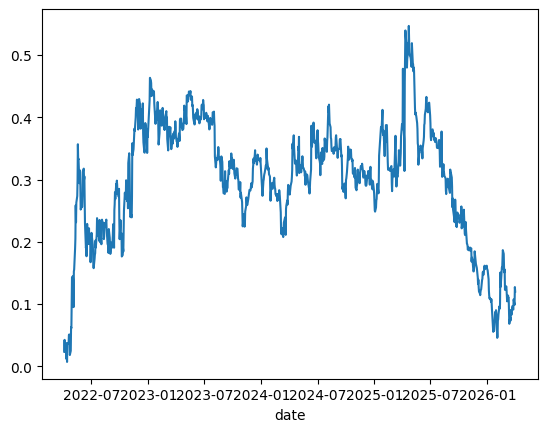

In [19]:
# Equity Curve
data['cum_trade_log_return'].plot()

In [20]:
# Win Rate
data['is_won'] = data['trade_log_return'] > 0
print(data)

                  open        high         low       close    volume  \
date                                                                   
2022-04-01  174.029999  174.880005  171.940002  174.309998  78751300   
2022-04-04  174.570007  178.490005  174.440002  178.440002  76468400   
2022-04-05  177.500000  178.300003  174.419998  175.059998  73401800   
2022-04-06  172.360001  173.630005  170.130005  171.830002  89058800   
2022-04-07  171.160004  173.360001  169.850006  172.139999  77594700   
...                ...         ...         ...         ...       ...   
2026-03-26  252.119995  257.000000  250.770004  252.889999  41796700   
2026-03-27  253.899994  255.490005  248.070007  248.800003  47900000   
2026-03-30  250.070007  250.869995  245.509995  246.630005  39446200   
2026-03-31  247.910004  255.479996  247.100006  253.789993  49598100   
2026-04-01  254.080002  256.179993  253.330002  255.630005  40059400   

            dividend  close_log_return  close_log_return_lag_1 

In [22]:
win_rate = data['is_won'].mean()
print(f"{win_rate*100}%")

 48.85343968095713%


In [23]:
# Total Gross Compound Return
r = np.exp(data['trade_log_return'].sum()) - 1
r

np.float64(0.12761011694646918)

In [24]:
data['trade_log_return'].mean()

np.float64(0.00011986073086162074)

In [25]:
data['trade_log_return'].std()

0.017715300420142733

In [26]:
data['trade_log_return'].mean() / data['trade_log_return'].std()

np.float64(0.0067659440155661225)

In [28]:
# Annualized Sharpe
Annualized_Sharpe = data['trade_log_return'].mean() / data['trade_log_return'].std() * np.sqrt(252)
print(Annualized_Sharpe)

0.10740603149864214
